# Executive Retail BI & Forecasting System — EDA

## Purpose
This notebook performs an executive-focused exploratory analysis on **Superstore sales transactions** to:
- Validate data quality for BI reporting and forecasting
- Quantify key business KPIs (sales, profit, margin, loss rate)
- Identify profitability drivers (discount, category, geography)
- Prepare a clean time series for monthly revenue forecasting

## Dataset
- File: `superstore_sales_clean.csv`
- Granularity: One row per **order line item**

## Imports & display settings

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-darkgrid")
pd.set_option("display.max_columns", None)

## 1. Load Data

We load the dataset from the raw data folder.  
At this stage we avoid transformations except for **type parsing** and **basic validation**, so we can detect issues early.

In [ ]:
# Load raw dataset (source-of-truth for EDA)
df = pd.read_csv("../data/raw/superstore_sales_clean.csv")

# Quick sample to confirm schema and values
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,OFF-TEN-10000025,Office Supplies,Storage,"Tenex Lockers, Blue",408.0,2.0,0.0,106.140,35.46,Medium,2011.0
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,OFF-SU-10000618,Office Supplies,Supplies,"Acme Trimmer, High Speed",120.0,3.0,0.1,36.036,9.72,Medium,2011.0
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,OFF-TEN-10001585,Office Supplies,Storage,"Tenex Box, Single Width",66.0,4.0,0.0,29.640,8.17,High,2011.0
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,OFF-PA-10001492,Office Supplies,Paper,"Enermax Note Cards, Premium",45.0,3.0,0.5,-26.055,4.82,High,2011.0
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,FUR-FU-10003447,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114.0,5.0,0.1,37.770,4.70,Medium,2011.0


## 2. Dataset Overview (Shape & Data Types)

This section answers:
- How large is the dataset?
- What are the columns and current dtypes?
- Are dates loaded as strings (common issue)?
- Are numeric columns incorrectly stored as float/object?

In [ ]:
# Quick overview of structure and missingness
df.info()

# Dataset size: rows = line items, columns = features
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  float64
 15  quantity        51290 non-null  float64
 16  discount        51290 non-null  float64
 17  profit          51290 non-null 

(51290, 21)

## Basic shape & schema

We confirm:
- Number of rows/columns (dataset scale)
- Data types (especially dates and numeric columns)
- Non-null counts (early detection of missingness)

Even though the dataset is “clean”, three things must be fixed for the every feature to be standardized.
- Dates Are Strings (`order_date`, `ship_date`)
- year Should NOT Be float64 (`year`)
- quantity Should Be Integer (`quantity`)

## 3. Date Parsing & Temporal Coverage

Dates must be parsed correctly because:
- BI reporting relies on consistent time aggregation
- Forecasting requires a reliable time series
- Shipping performance depends on accurate order/ship dates

We use `errors="raise"` to avoid silent parsing failures.

In [60]:
# Parse date columns robustly (handles mixed date formats)
df["order_date"] = pd.to_datetime(
    df["order_date"],
    format="mixed",
    dayfirst=True,
    errors="raise"
)

df["ship_date"] = pd.to_datetime(
    df["ship_date"],
    format="mixed",
    dayfirst=True,
    errors="raise"
)

# Confirm date parsing results (range + distribution)
df[["order_date", "ship_date"]].describe()

,order_date,ship_date
count,51290,51290
mean,2013-05-11 21:26:49.155780864,2013-05-15 20:42:42.745174528
min,2011-01-01 00:00:00,2011-01-03 00:00:00
25%,2012-06-19 00:00:00,2012-06-23 00:00:00
50%,2013-07-08 00:00:00,2013-07-12 00:00:00
75%,2014-05-22 00:00:00,2014-05-26 00:00:00
max,2014-12-31 00:00:00,2015-01-07 00:00:00


### 3.1 Confirm Date Types

We verify that both columns are now `datetime64[ns]` to support:
- monthly grouping
- shipping time calculations
- time series forecasting

In [25]:
df[["order_date", "ship_date"]].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   order_date  51290 non-null  datetime64[ns]
 1   ship_date   51290 non-null  datetime64[ns]
dtypes: datetime64[ns](2)
memory usage: 801.5 KB


### Date dtype confirmation

Quick check that both columns are now true datetime fields (required for:
- time-series aggregation
- forecasting
- shipping lead-time calculations)

## 4. Type Fixes (Business-Safe Casting)

Two columns should be integer-like:
- `year`: a calendar year, not a float
- `quantity`: number of items sold per line item

Casting improves:
- storage efficiency
- correctness of aggregations
- downstream database schema integrity (PostgreSQL)

### Standardizing `year` Data type

In [ ]:
# Convert year and quantity to integer types for correctness
df["year"] = df["year"].astype(int)
df["quantity"] = df["quantity"].astype(int)

df[["year", "quantity"]].dtypes

year        int64
quantity    int64
dtype: object

## 5. Shipping Performance Feature (Shipping Days)

We compute `shipping_days` because it is:
- a useful operational KPI for executives
- a potential driver of profit (shipping cost & delays can reduce margin)

We also sanity-check for negative values.

In [61]:
# Compute shipping duration in days
df["shipping_days"] = (df["ship_date"] - df["order_date"]).dt.days

# Sanity check: shipping days should not be negative
assert (df["shipping_days"] >= 0).all(), "Found negative shipping days. Check date parsing."

df["shipping_days"].describe()

count    51290.000000
mean         3.969370
std          1.729437
min          0.000000
25%          3.000000
50%          4.000000
75%          5.000000
max          7.000000
Name: shipping_days, dtype: float64

## 6. Data Quality Checks

We check:
- Missing rate per column (BI & models break with nulls)
- Exact duplicates (inflates KPIs)
- Numeric ranges (detect outliers and invalid values)

This is critical before loading to PostgreSQL and building dashboards.

### Missingness

In [ ]:
# Column-level missing rate (0.00 = no missing)
missing_rate = df.isnull().mean().sort_values(ascending=False)
missing_rate

order_id          0.0
order_date        0.0
year              0.0
order_priority    0.0
shipping_cost     0.0
profit            0.0
discount          0.0
quantity          0.0
sales             0.0
product_name      0.0
sub_category      0.0
category          0.0
product_id        0.0
region            0.0
market            0.0
country           0.0
state             0.0
segment           0.0
customer_name     0.0
ship_mode         0.0
ship_date         0.0
shipping_days     0.0
dtype: float64

### Duplicates

In [ ]:
# Duplicate rows can inflate revenue/profit and mislead dashboards
df.duplicated().sum()

np.int64(0)

### Numeric distribution

In [31]:
numeric_cols = ["sales", "quantity", "discount", "profit", "shipping_cost"]
df[numeric_cols].describe()

,sales,quantity,discount,profit,shipping_cost
count,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,246.498440,3.476545,0.142908,28.641740,26.375915
std,487.567175,2.278766,0.212280,174.424113,57.296804
min,0.000000,1.000000,0.000000,-6599.978000,0.000000
25%,31.000000,2.000000,0.000000,0.000000,2.610000
50%,85.000000,3.000000,0.000000,9.240000,7.790000
75%,251.000000,5.000000,0.200000,36.810000,24.450000
max,22638.000000,14.000000,0.850000,8399.976000,933.570000


### 6.1 Numeric Sanity Check

We validate key financial metrics:
- `sales` should be non-negative (0 may represent canceled/edge cases)
- `discount` should be within reasonable bounds (0–1)
- `profit` can be negative (loss-making transactions)
- `shipping_cost` should be non-negative

We capture distribution and potential outliers for later KPI design.

## 7. Granularity Check (Orders vs Line Items)

To avoid wrong interpretation:
- Rows represent **line items**, not orders.
- We compute unique orders to support order-based KPIs (e.g., AOV).

This distinction is important for executive reporting.

In [32]:
df["order_id"].nunique(), df.shape[0]

(25035, 51290)

## 8. Core Business KPIs (Executive Snapshot)

We compute:
- Total Sales
- Total Profit
- Profit Margin (%)
- Total Orders
- Loss-making transaction rate

These are the anchor KPIs that appear in the Power BI executive summary.

In [ ]:
# % of line items with negative profit (signals discount/logistics issues)
loss_rate = (df["profit"] < 0).mean()
print(f"Profit Loss Rate: {loss_rate * 100:.2f}%")

summary_metrics = {
    "Total Sales": df["sales"].sum(),
    "Total Profit": df["profit"].sum(),
    "Profit Margin (%)": (df["profit"].sum() / df["sales"].sum()) * 100,
    "Total Orders": df["order_id"].nunique()
}

summary_metrics

Profit Loss Rate: 24.46%


{'Total Sales': np.float64(12642905.0),
 'Total Profit': np.float64(1469034.82128),
 'Profit Margin (%)': np.float64(11.619440478908922),
 'Total Orders': 25035}

## 9. Monthly Revenue Time Series (Forecasting Input)

For forecasting, we aggregate sales by month using `order_date`:
- reduces noise from daily spikes
- aligns with executive planning cycles
- produces a stable series for SARIMA/Prophet

This table will later be used in the forecasting notebook/script.

In [56]:
monthly_sales = (
    df.groupby(pd.Grouper(key="order_date", freq="ME"))["sales"]
    .sum()
    .reset_index()
    .sort_values("order_date")
)

monthly_sales.head()

,order_date,sales
0,2011-01-31,98902.0
1,2011-02-28,91152.0
2,2011-03-31,145726.0
3,2011-04-30,116927.0
4,2011-05-31,146762.0


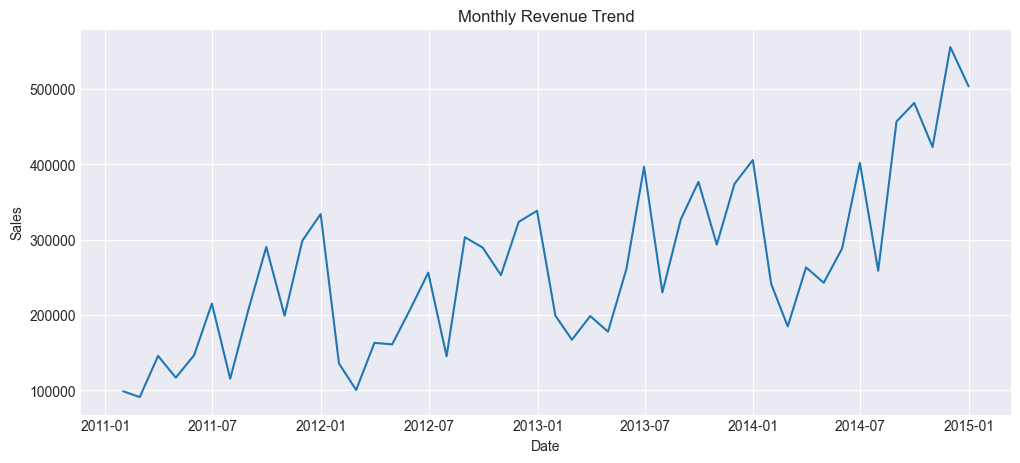

In [40]:
plt.figure(figsize=(12,5))
plt.plot(monthly_sales["order_date"], monthly_sales["sales"])
plt.title("Monthly Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

## 10. Category Performance (Revenue & Profit)

Executives care about:
- which categories drive revenue
- which categories drive profit (not always the same)

We compute both to identify margin efficiency differences.

In [41]:
category_sales = (
    df.groupby("category")["sales"]
    .sum()
    .sort_values(ascending=False)
)

category_sales

category
Technology         4744691.0
Furniture          4110884.0
Office Supplies    3787330.0
Name: sales, dtype: float64

### Profitability by category

In [42]:
category_profit = (
    df.groupby("category")["profit"]
    .sum()
    .sort_values(ascending=False)
)

category_profit

category
Technology         663778.73318
Office Supplies    518473.83430
Furniture          286782.25380
Name: profit, dtype: float64

## 11. Discount vs Profit Relationship

Discounting is often a key driver of loss-making transactions.

We visualize profit against discount to check for:
- profit erosion at high discount levels
- clusters of negative profit at certain discount bands

This directly informs pricing/discount strategy recommendations.

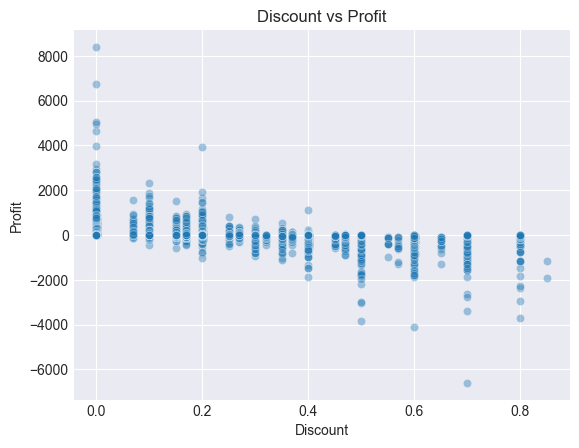

In [57]:
sns.scatterplot(data=df, x="discount", y="profit", alpha=0.4)
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()

## 12. Geographic Performance (Market & Region)

We quantify:
- Sales contribution by market
- Profit contribution by region

This helps identify:
- growth markets (high sales)
- efficiency markets (high profit)
- potential operational issues (low profit despite sales)

In [44]:
market_sales = (
    df.groupby("market")["sales"]
    .sum()
    .sort_values(ascending=False)
)

market_sales

market
APAC      3585833.0
EU        2938139.0
US        2297354.0
LATAM     2164687.0
EMEA       806184.0
Africa     783776.0
Canada      66932.0
Name: sales, dtype: float64

In [65]:
region_profit = (
    df.groupby("region")["profit"]
    .sum()
    .sort_values(ascending=False)
)

region_profit

region
Central           311403.98164
North             194597.95252
North Asia        165578.42100
South             140355.76618
Central Asia      132480.18700
Oceania           121666.64200
West              108418.44890
East               91522.78000
Africa             88871.63100
EMEA               43897.97100
Caribbean          34571.32104
Southeast Asia     17852.32900
Canada             17817.39000
Name: profit, dtype: float64

## 13. Additional Data Guardrails

Before productionizing KPIs, we check for:
- unusually high discounts (potential outliers)
- edge cases that could distort executive dashboards

These checks feed into ETL validation rules in Day 2.

In [63]:
# Fraction of transactions with very high discount (>50%)
(df["discount"] > 0.5).mean() * 100

np.float64(8.134139208422694)

# Summary — Key Findings

## Data Quality
- 51,290 line items across 25,035 unique orders
- No missing values and no duplicates detected
- Date coverage: 2011-01-01 to 2014-12-31 (shipments extend to early 2015)
- Average shipping duration is ~4 days (0–7 days range)

## Business Snapshot
- Total Sales: ~$12.6M
- Total Profit: ~$1.47M
- Profit Margin: ~11.6%
- ~24.5% of line items are loss-making

## Drivers & Patterns
- Technology leads in both revenue and profit
- Furniture is high-revenue but lower-profit efficiency (margin opportunity)
- APAC is the top market by revenue
- Profitability varies significantly by region
- High discounting exists (>50% discount on ~8% of transactions), likely contributing to losses

In [67]:
df['ship_mode'].value_counts().sort_index()

ship_mode
First Class        7505
Same Day           2701
Second Class      10309
Standard Class    30775
Name: count, dtype: int64